<a href="https://colab.research.google.com/github/RazyAnas/MachineLearning/blob/main/Stochastic_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem with Batch GD

for single coefficient we calculate 1000 derivatives if n = 1000 (rows)

col - 5 --> 6 coefficient

so, 6000 derivatives

and epochs = 50, therefore 300000 derivatives

exponentially number of derivatives and computation increases. Very slow computation on big data.

1. using vectorisation we reduce this but still if the X_train is too big too much load on RAM and system requirement - memory out

2. Hardware


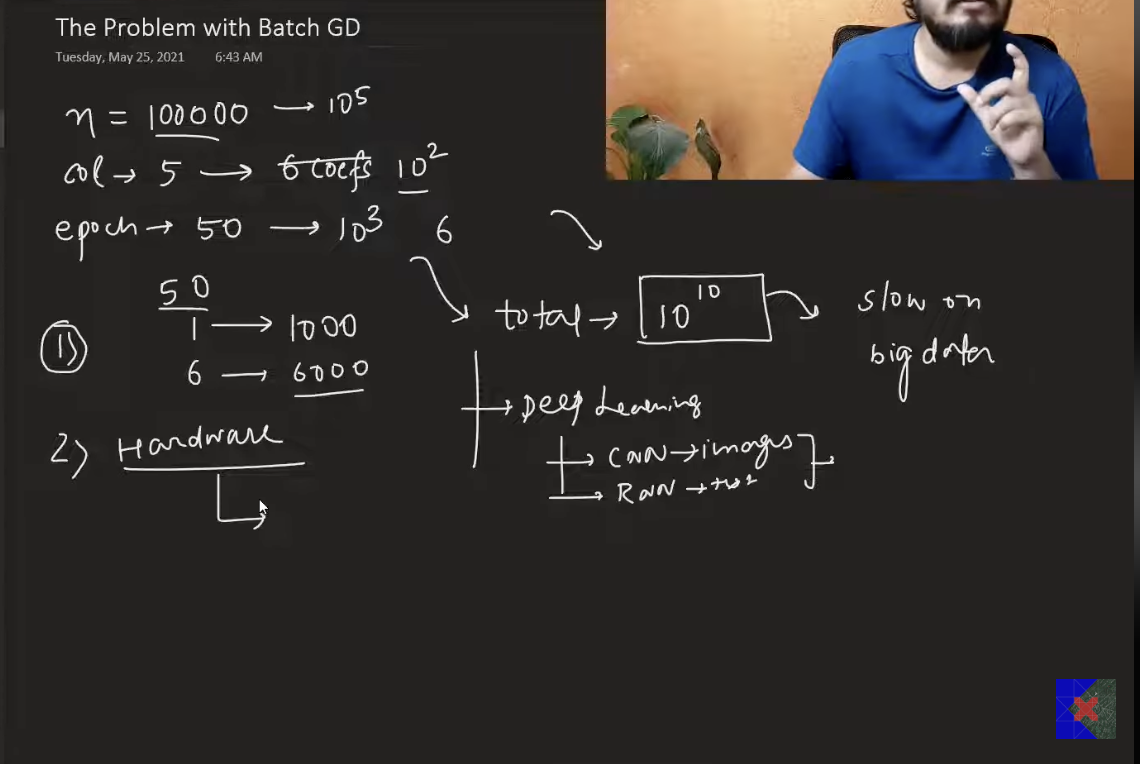

# Stochastic Gradient Descent

**Batch GD:** we were updating the coef, intercept after each loop, single update after fully viewing whole data. 1 epoch 1 update. More epochs needed. whole data need to be loaded. Hardware requirements may exceed. used for small data.

**Stochastic GD:** we update after each row, in 1 epoch we update n times. Faster converging to our result depending on the data. Requires less number of epochs. 1 iteration single row. Hardware requirements dont exceed. First loop doesnt mean first row, we select row randomly out of n rows.

The word stochastic means: "Stochastic is a term meaning randomly determined; having a pattern or variable that can be analyzed statistically but not predicted precisely"

Drawback: not steady answer. Randomness has its own beauty.

# Code

In [1]:
from sklearn.datasets import load_diabetes

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [2]:
X, y = load_diabetes(return_X_y=True)

In [3]:
print(X.shape)
print(y.shape)

(442, 10)
(442,)


In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [5]:
reg = LinearRegression()

In [6]:
reg.fit(X_train, y_train)

LinearRegression()

In [7]:
print(reg.coef_)
print(reg.intercept_)

[  -9.15865318 -205.45432163  516.69374454  340.61999905 -895.5520019
  561.22067904  153.89310954  126.73139688  861.12700152   52.42112238]
151.88331005254167


In [8]:
y_pred = reg.predict(X_test)
r2_score(y_test, y_pred)

0.4399338661568968

In [18]:
class SGDRegressor:
  def __init__(self, learning_rate=0.01, epochs=100):
    self.coef_ = None
    self.intercept_ = None
    self.lr = learning_rate
    self.epochs = epochs

  def fit(self, X_train, y_train):

    # initialize your all coefs and intercept
    self.intercept_ = 0
    # X_train shape = n and n+1 = no. of coefs
    self.coef_ = np.ones(X_train.shape[1])

    # loop and update all coefs and intercept
    for i in range(self.epochs):
      for j in range(X_train.shape[0]): # jitna rows
        idx = np.random.randint(0, X_train.shape[0]) # random integer in the range of rows index

        # INTERCEPT
        # we will calculate prediction for particular index
        y_hat = np.dot(X_train[idx], self.coef_) + self.intercept_
        # if we are working on single row then we dont need the summation or m = 1
        # therefore mean not needed
        # intercept_der = -2 * np.mean(y_train - y_hat)
        intercept_der = -2 * (y_train[idx] - y_hat) # y_hat already single value
        self.intercept_  = self.intercept_ - (self.lr * intercept_der)

        # COEFFICIENTS
        # coef_der = -2 * np.dot((y_train - y_hat), X_train) / X_train.shape[0]
        # we dont need summation and n= 1 and we need only single row value if Xi1 then it will be X_train[idx]
        coef_der = -2 * np.dot((y_train[idx] - y_hat), X_train[idx]) # 10, 1 dot 1, 1 will give 10 numbers of 1 shaped answer
        self.coef_ = self.coef_ - (self.lr * coef_der)

    print(self.intercept_, self.coef_)

  def predict(self, X_test):
    return np.dot(X_test, self.coef_) + self.intercept_


In [20]:
# X_train[12]

array([ 0.0090156 ,  0.05068012, -0.00512814, -0.06419889,  0.06998059,
        0.0838625 , -0.03971921,  0.07120998,  0.03954249,  0.01963284])

In [21]:
# coef_ = np.ones(X_train.shape[1])
# coef_

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [23]:
# intercept_ = 0

In [24]:
# np.dot(X_train[12], coef_) + intercept_

np.float64(0.2348778827794737)

In [25]:
sgd = SGDRegressor(learning_rate=0.01, epochs=50)

In [26]:
sgd.fit(X_train, y_train)

150.47954834728546 [  55.3001537   -78.28400551  346.65003936  244.16951213   13.72911089
  -35.68314829 -168.91016025  124.89896037  319.36666571  125.73942348]


In [27]:
y_pred = sgd.predict(X_test)

In [29]:
r2_score(y_test, y_pred)

0.4349292796266362

> It converges faster to the result, but solution will be different each time

# Time Comparision

For equal number of epochs - Batch is faster

for same number of epochs lets say 100
- batch updates 100 times
- SGD updates 100*n times

But Stochatic dont need these much epochs, SGD converges faster to the result

# Visualization

BATCH | SGD

instead of epoch its update

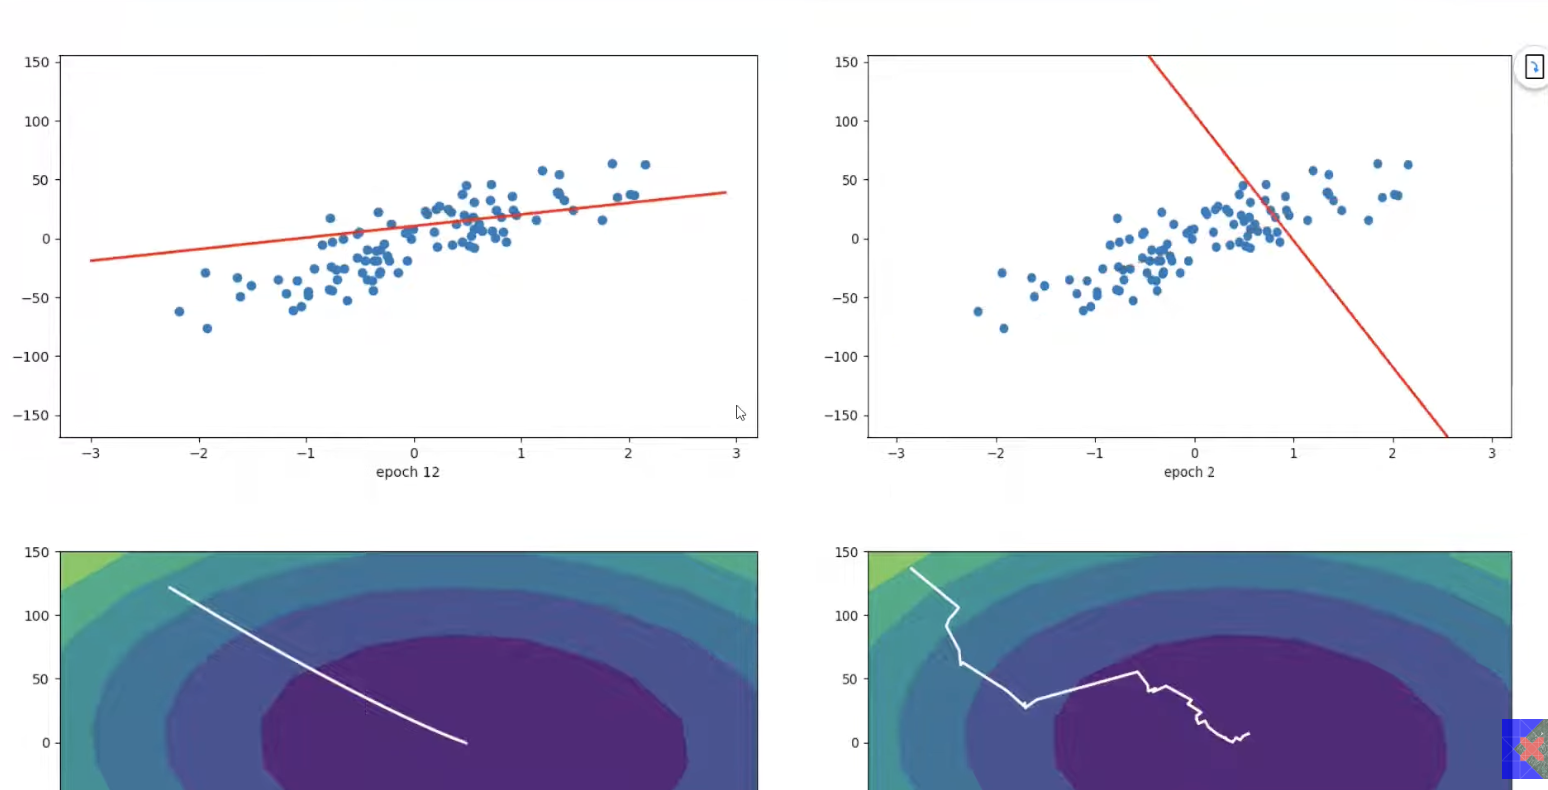

# When to use Stochastic GD

1. Big data -> SGD converge faster
2. When you have a non-convex function

 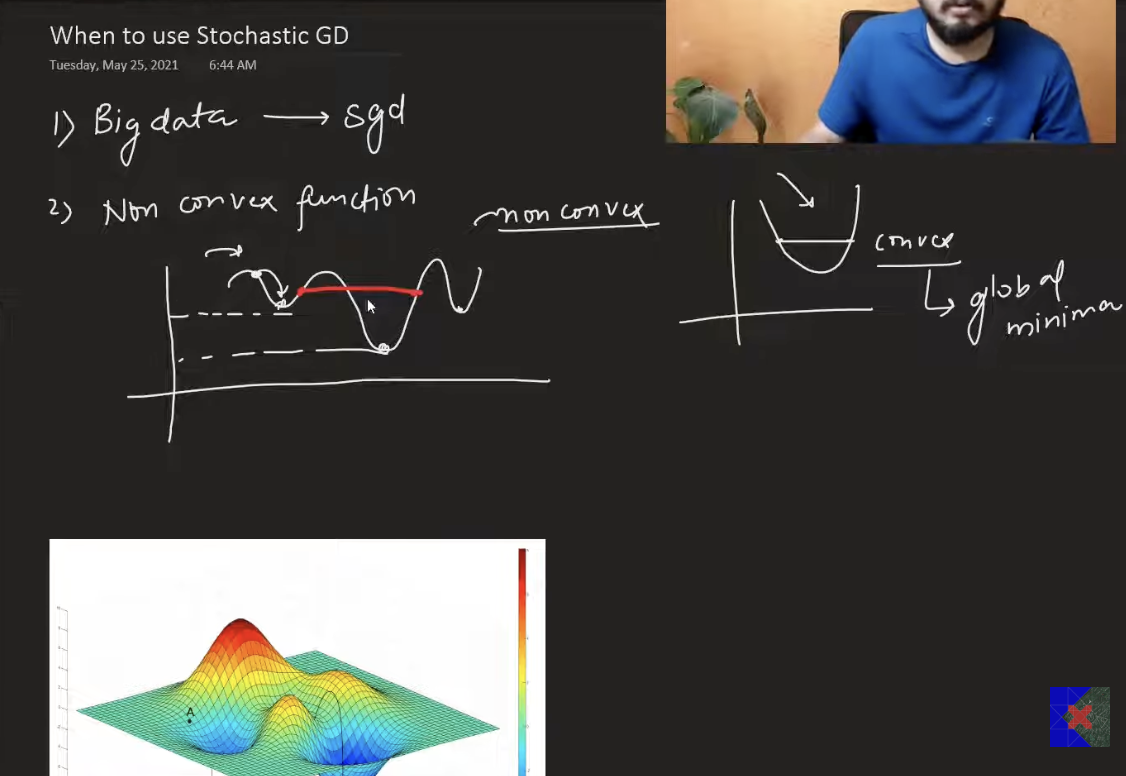

fluctuation not a good thing

to solve we use learning schedule in which we vary learning rate.

# Learning Schedules

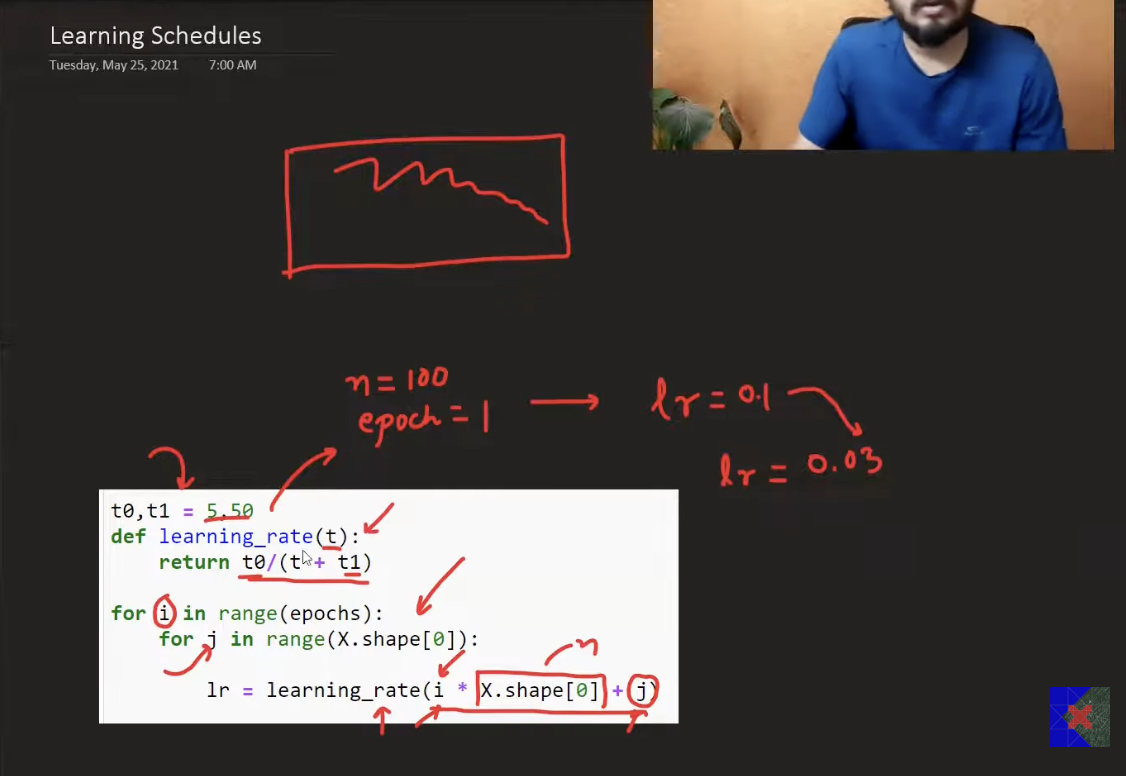

Used a lot in Deep Learning

# SGDRegression scikit

- It can work on different types of loss functions
- It can work for different algorithms
- can apply regularization
- epochs
- tolerance - best solution based on previous iteration
- shuffle - randomness

In [51]:
from sklearn.linear_model import SGDRegressor

In [56]:
reg = SGDRegressor(max_iter=100, learning_rate='constant', eta0=0.01)

In [57]:
reg.fit(X_train, y_train)

SGDRegressor(learning_rate='constant', max_iter=100)

In [58]:
y_pred = reg.predict(X_test)

In [59]:
r2_score(y_test, y_pred)

0.6330389714919435